# Chapter 8: Stochastic Models


> **Source and scope.** This is an original computational companion to Mark M. Meerschaert, *Mathematical Modeling*, 4th ed. (Academic Press, 2013). It follows the chapter structure and reconstructs representative models in Python. It does not reproduce the textbook's prose, figures, or complete exercise sets. Equations, numerical assumptions, and example names are attributed to the book.


This notebook follows Sections 8.1-8.4: Markov chains, continuous-time Markov processes, linear regression, and autoregressive time-series models.


In [1]:
from __future__ import annotations

import platform
import warnings
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sympy as sp
from IPython.display import display

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.precision", 6)
plt.rcParams["figure.figsize"] = (8, 4.8)

SEED = 20260731
rng = np.random.default_rng(SEED)

versions = pd.Series({
    "Python": platform.python_version(),
    "NumPy": np.__version__,
    "SciPy": scipy.__version__,
    "SymPy": sp.__version__,
    "pandas": pd.__version__,
    "Matplotlib": version("matplotlib"),
}, name="version")
display(versions.to_frame())

import statsmodels.api as sm
from statsmodels.tsa.stattools import acf


,version
Python,3.13.5
NumPy,2.3.5
SciPy,1.17.0
SymPy,1.14.0
pandas,2.2.3
Matplotlib,3.10.8


## 8.1 Markov chains and steady-state distributions

A row probability vector evolves by \(\pi_{n+1}=\pi_nP\). In steady state, \(\pi=\pi P\) and the probabilities sum to one.


Steady-state distribution: [0.552632 0.263158 0.184211]


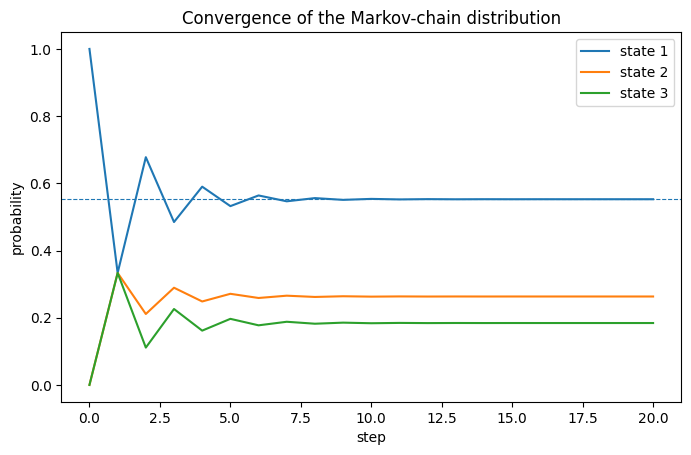

In [2]:
P = np.array([
    [1/3, 1/3, 1/3],
    [0.7, 0.3, 0.0],
    [1.0, 0.0, 0.0],
])
pi = np.array([1.0, 0.0, 0.0])
history = [pi.copy()]
for _ in range(20):
    pi = pi @ P
    history.append(pi.copy())
history = np.vstack(history)

A = np.vstack([P.T - np.eye(3), np.ones(3)])
b = np.r_[np.zeros(3), 1.0]
steady, *_ = np.linalg.lstsq(A, b, rcond=None)

print("Steady-state distribution:", steady)
assert np.allclose(steady @ P, steady)

for state in range(3):
    plt.plot(history[:, state], label=f"state {state + 1}")
plt.axhline(steady[0], linestyle="--", linewidth=0.8)
plt.xlabel("step")
plt.ylabel("probability")
plt.title("Convergence of the Markov-chain distribution")
plt.legend()
plt.show()


### Aquarium inventory chain

Weekly demand is Poisson with mean one. The state is beginning-of-week inventory in \(\{1,2,3\}\). The current policy replenishes to three only after a stockout.


In [3]:
P_inventory = np.array([
    [0.368, 0.000, 0.632],
    [0.368, 0.368, 0.264],
    [0.184, 0.368, 0.448],
])
A_inv = np.vstack([P_inventory.T - np.eye(3), np.ones(3)])
b_inv = np.r_[np.zeros(3), 1.0]
pi_inventory, *_ = np.linalg.lstsq(A_inv, b_inv, rcond=None)

lost_by_state = np.array([0.264, 0.080, 0.019])
lost_probability = float(pi_inventory @ lost_by_state)

display(pd.Series({
    "pi(inventory=1)": pi_inventory[0],
    "pi(inventory=2)": pi_inventory[1],
    "pi(inventory=3)": pi_inventory[2],
    "long-run lost-sale probability": lost_probability,
}, name="value").to_frame())

assert np.isclose(lost_probability, 0.105, atol=0.002)


,value
pi(inventory=1),0.284835
pi(inventory=2),0.263181
pi(inventory=3),0.451984
long-run lost-sale probability,0.104839


## 8.2 Continuous-time Markov process: forklift repair

The repair facility is a finite birth-death process with arrival rate \(\lambda=4.5\) per month, service rate \(\mu=7.3\), and capacity 27. Its steady state is a truncated geometric distribution.


,value
traffic intensity rho,0.616438
mechanic busy probability,0.616438
expected forklifts in repair,1.607106
probability of 5 or more,0.089011


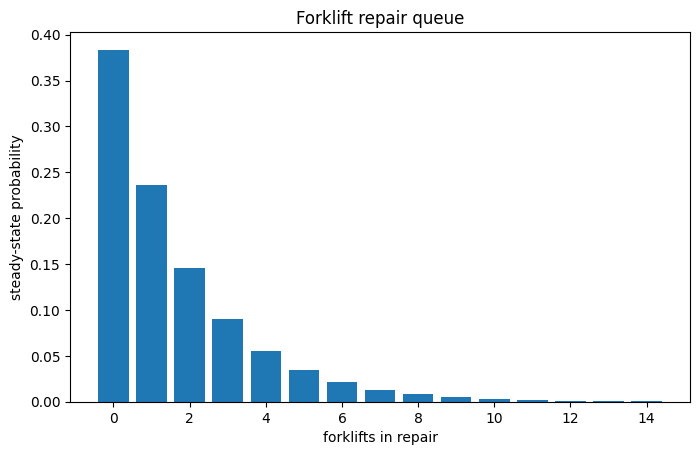

In [4]:
arrival_rate, service_rate, K = 4.5, 7.3, 27
rho = arrival_rate / service_rate
p0 = (1 - rho) / (1 - rho ** (K + 1))
states = np.arange(K + 1)
probability = p0 * rho**states
busy_probability = 1 - probability[0]
expected_in_system = np.sum(states * probability)

forklift = pd.Series({
    "traffic intensity rho": rho,
    "mechanic busy probability": busy_probability,
    "expected forklifts in repair": expected_in_system,
    "probability of 5 or more": probability[5:].sum(),
})
display(forklift.to_frame("value"))

plt.bar(states[:15], probability[:15])
plt.xlabel("forklifts in repair")
plt.ylabel("steady-state probability")
plt.title("Forklift repair queue")
plt.show()

assert np.isclose(busy_probability, 0.616, atol=0.002)
assert np.isclose(expected_in_system, 1.607, atol=0.01)


## 8.3 Linear regression: CM1 mortgage index

The dataset in `data/cm1.csv` transcribes the CM1 column of the chapter's Table 8.1. We fit \(X_t=a+bt+\varepsilon_t\) and predict month \(t=48\).


In [5]:
from pathlib import Path

candidates = [Path("data/cm1.csv"), Path("../data/cm1.csv")]
for candidate in candidates:
    if candidate.exists():
        cm1 = pd.read_csv(candidate)
        break
else:
    raise FileNotFoundError("Could not locate data/cm1.csv")

display(cm1.head())
X = sm.add_constant(cm1[["t"]])
linear_model = sm.OLS(cm1["cm1"], X).fit()
print(linear_model.summary())

prediction_48 = linear_model.get_prediction(pd.DataFrame({"const": [1.0], "t": [48]})).summary_frame(alpha=0.05)
display(prediction_48)
assert np.isclose(linear_model.params["const"], 5.4475, atol=1e-3)
assert np.isclose(linear_model.params["t"], 0.096989, atol=1e-5)


,month,t,cm1
0,1986-06,1,6.73
1,1986-07,2,6.27
2,1986-08,3,5.93
3,1986-09,4,5.77
4,1986-10,5,5.72


                            OLS Regression Results                            
Dep. Variable:                    cm1   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                     171.4
Date:                Fri, 31 Jul 2026   Prob (F-statistic):           4.79e-15
Time:                        01:06:42   Log-Likelihood:                -24.408
No. Observations:                  37   AIC:                             52.82
Df Residuals:                      35   BIC:                             56.04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.4475      0.161     33.734      0.0

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,10.102954,0.228969,9.638123,10.567785,9.021109,11.184799


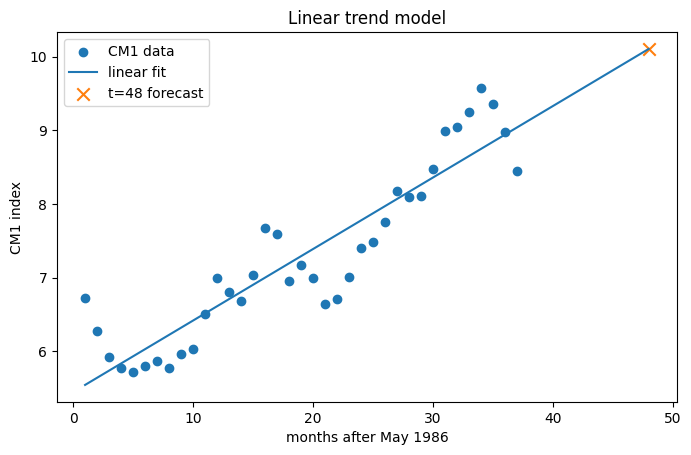

In [6]:
plt.scatter(cm1["t"], cm1["cm1"], label="CM1 data")
plot_t = np.linspace(1, 48, 200)
plt.plot(plot_t, linear_model.params["const"] + linear_model.params["t"] * plot_t, label="linear fit")
plt.scatter([48], [prediction_48["mean"].iloc[0]], marker="x", s=80, label="t=48 forecast")
plt.xlabel("months after May 1986")
plt.ylabel("CM1 index")
plt.title("Linear trend model")
plt.legend()
plt.show()


## 8.4 Time series: trend plus AR(1)

The refined model is

\[
X_t=a+bt+c_1X_{t-1}+\varepsilon_t.
\]

It captures serial dependence left in the simple regression residuals.


In [7]:
ar_data = pd.DataFrame({
    "y": cm1["cm1"].iloc[1:].to_numpy(),
    "t": cm1["t"].iloc[1:].to_numpy(),
    "lag1": cm1["cm1"].iloc[:-1].to_numpy(),
})
ar_model = sm.OLS(ar_data["y"], sm.add_constant(ar_data[["t", "lag1"]])).fit()
print(ar_model.summary())

forecast_values = list(cm1["cm1"].to_numpy())
for future_t in range(38, 49):
    next_value = (
        ar_model.params["const"]
        + ar_model.params["t"] * future_t
        + ar_model.params["lag1"] * forecast_values[-1]
    )
    forecast_values.append(float(next_value))
ar_forecast_48 = forecast_values[-1]
residual_sigma = np.sqrt(ar_model.ssr / ar_model.df_resid)

ar_summary = pd.Series({
    "a": ar_model.params["const"],
    "b": ar_model.params["t"],
    "c1": ar_model.params["lag1"],
    "R^2": ar_model.rsquared,
    "residual sigma": residual_sigma,
    "forecast X48": ar_forecast_48,
    "approx 95% lower": ar_forecast_48 - 2 * residual_sigma,
    "approx 95% upper": ar_forecast_48 + 2 * residual_sigma,
})
display(ar_summary.to_frame("value"))

assert np.isclose(ar_model.params["const"], 1.5987, atol=0.01)
assert np.isclose(ar_model.params["lag1"], 0.6977, atol=0.01)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.941
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     264.8
Date:                Fri, 31 Jul 2026   Prob (F-statistic):           4.77e-21
Time:                        01:06:42   Log-Likelihood:                -5.0105
No. Observations:                  36   AIC:                             16.02
Df Residuals:                      33   BIC:                             20.77
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5987      0.565      2.829      0.0

,value
a,1.598660
b,0.032988
c1,0.697668
R^2,0.941333
residual sigma,0.290471
forecast X48,10.261277
approx 95% lower,9.680335
approx 95% upper,10.842219


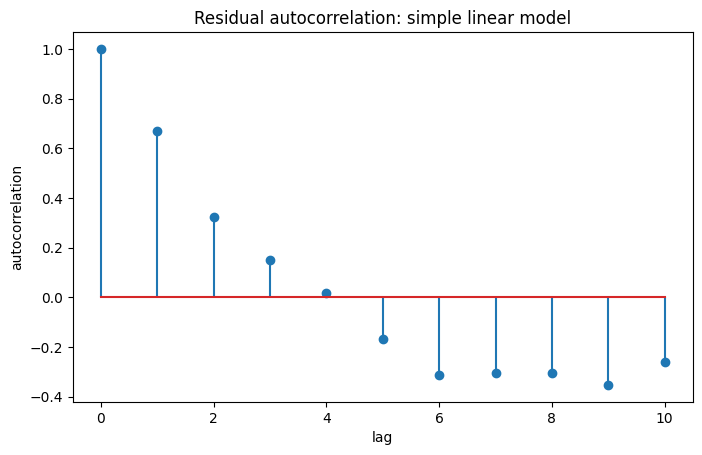

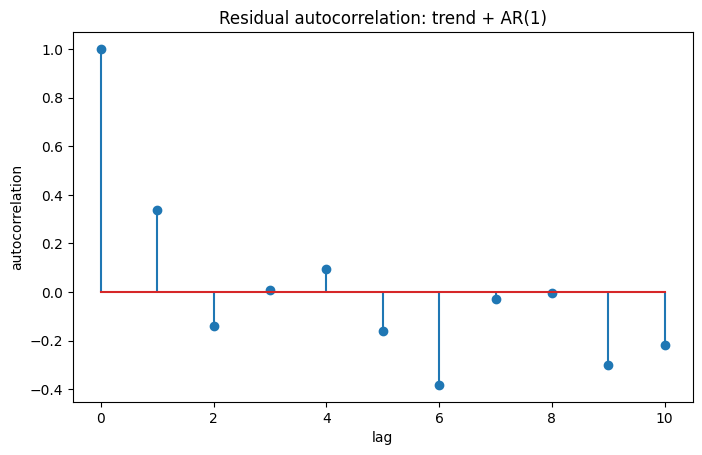

In [8]:
linear_acf = acf(linear_model.resid, nlags=10, fft=False)
ar_acf = acf(ar_model.resid, nlags=10, fft=False)
lags = np.arange(len(linear_acf))

plt.stem(lags, linear_acf, label="linear residuals")
plt.xlabel("lag")
plt.ylabel("autocorrelation")
plt.title("Residual autocorrelation: simple linear model")
plt.show()

plt.stem(lags, ar_acf, label="AR(1) residuals")
plt.xlabel("lag")
plt.ylabel("autocorrelation")
plt.title("Residual autocorrelation: trend + AR(1)")
plt.show()


## Chapter checkpoint

Markov models replace deterministic state trajectories with evolving probability distributions. Regression models the mean structure; autoregression adds serial dependence. In every case, the state must contain enough information to determine the probabilistic future, otherwise the alleged state is merely an optimistic memo.
